# V3 Changes



# Setup

In [2]:
import os
import json
import math
from pathlib import Path

from __future__ import annotations
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class PreprocessingConfig:
    # Windowing parameters
    window_size: int = 250 #200

    # Step size for sliding window (overlap = window_size - step_size)
    step_size: int = 25 #50

    # 0 means "umarked" in the dataset, those windows will be dropped during training
    drop_label_values: Tuple[int, ...] = (0, 7,)

    # Enforce sorting by time, which is important for some preprocessing steps (e.g., windowing)
    sort_by_time: bool = True

cfg = PreprocessingConfig()

root_dir = Path("/Users/tonyliu/Documents/EMGTuner-master/data")
DATA_FILES = [str(file) for file in root_dir.rglob("*.txt") if file.name != "README.txt"]



# Load Files

In [3]:
def load_emg_file(path: str | Path) -> pd.DataFrame:
    path = Path(path)

    # Try common delimiters until we find one that works
    for sep in [",", "\t", r"\s+"]:
        try:
            df = pd.read_csv(path, sep = sep, engine = "python")

            # Require at least two columns
            if len(df.columns) > 1:
                return df
            
        except Exception:
            continue
    
    raise ValueError(f"Could not parse file {path} with common delimiters")

def infer_columns(df: pd.DataFrame) -> Dict[str, List[str] | str]:
    cols = {c.lower(): c for c in df.columns}

    # Infer time column
    time_col = None
    for name in ["time", "timestamp", "t"]:
        if name in cols:
            time_col = cols[name]
            break
    
    # Assume first column is time if no match
    if time_col is None:
        time_col = df.columns[0] 

    # Infer label column
    label_col = None
    for name in ["label", "class", "target", "gesture"]: 
        if name in cols:
            label_col = cols[name]
            break
    
    # Assume last column is label if no match
    if label_col is None:
        label_col = df.columns[-1]
    
    # Infer channel columns
    chanel_cols = []
    for col in df.columns:
        col_lower = col.lower()
        if col_lower == time_col.lower() or col_lower == label_col.lower():
            continue
        if "channel" in col_lower or col_lower.startswith("ch"):
            chanel_cols.append(col)
    
    # If no channel columns found, assume all non-time, non-label columns are channels
    if len(chanel_cols) == 0:
        possible_channel_cols = [col for col in df.columns if col != time_col and col != label_col]
        numeric_cols = []

        for col in possible_channel_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                numeric_cols.append(col)
        
        chanel_cols = numeric_cols

    if len(chanel_cols) == 0:
        raise ValueError("Could not infer any channel columns")
    
    return {"time_col": time_col, "label_col": label_col, "channel_cols": chanel_cols}

all_dfs = []
schemas = []

for file in DATA_FILES:
    df = load_emg_file(file)
    info = infer_columns(df)

    # Standardize column names
    time_col = info["time_col"]
    label_col = info["label_col"]
    channel_cols = info["channel_cols"]

    cols = [time_col] + channel_cols + [label_col]
    df = df[cols].copy()
    df = df.rename(columns = {time_col: "time", label_col: "label"})

    # Keep channels as is
    channels = [col for col in df.columns if col not in ["time", "label"]]
    df = df[["time"] + channels + ["label"]]

    df["source_file"] = str(file)
    df["source_index"] = np.arange(len(df), dtype = np.int64)

    if cfg.sort_by_time:
        df = df.sort_values("time", kind = "mergesort").reset_index(drop = True)
    
    all_dfs.append(df)
    schemas.append({
        "file": str(file),
        "num_rows": len(df),
        "channels": channels,
        "time_dtype": str(df["time"].dtype),
        "label_dtype": str(df["label"].dtype),
        "n_channels": len(channels),
    })

raw_df = pd.concat(all_dfs, ignore_index = True)
schemas_df = pd.DataFrame(schemas)

# Apply Filters

In [4]:
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt

def calculate_sampling_rate(time_series: np.ndarray) -> float:
    t = np.asarray(time_series, dtype = np.float64)
    dt_ms = np.median(np.diff(t))

    if dt_ms <= 0:
        raise ValueError("Non-positive time differences found, cannot calculate sampling rate")
    
    fs = 1000.0 / dt_ms
    return float(fs)

# Calculate sampling rate for each file
fs_by_file = {}
for src, sub in raw_df.groupby("source_file", sort = False):
    fs_by_file[src] = calculate_sampling_rate(sub["time"].to_numpy())

def design_bandpass_filter(fs: float, low_hz = 20.0, high_hz = 450.0, order = 4):
    nyquist = 0.5 * fs
    low = low_hz / nyquist
    high = high_hz / nyquist

    if not (0 < low < 1 and 0 < high < 1):
        raise ValueError("Invalid cutoff frequencies for bandpass filter")

    sos = butter(order, [low, high], btype = "bandpass", output = "sos")
    return sos

def apply_bandpass_filter(X: np.ndarray, fs: float, low_hz = 20.0, high_hz = 450.0, order = 4) -> np.ndarray:
    sos = design_bandpass_filter(fs, low_hz, high_hz, order)
    
    if X.ndim == 2:
        return sosfiltfilt(sos, X, axis = 0).astype(np.float32)
    elif X.ndim == 3:
        return sosfiltfilt(sos, X, axis = 1).astype(np.float32)
    else:
        raise ValueError("Input data must be 2D or 3D array")

def apply_notch_filter(X: np.ndarray, fs: float, notch_hz = 60.0, quality_factor = 30.0) -> np.ndarray:
    nyquist = 0.5 * fs
    w0 = notch_hz / nyquist

    if not (0 < w0 < 1):
        raise ValueError("Invalid notch frequency for notch filter")
    
    b, a = iirnotch(w0, quality_factor)

    if X.ndim == 2:
        return filtfilt(b, a, X, axis = 0).astype(np.float32)
    elif X.ndim == 3:
        return filtfilt(b, a, X, axis = 1).astype(np.float32)
    else:
        raise ValueError("Input data must be 2D or 3D array")

def filter_emg_data(df: pd.DataFrame, channel_cols: list[str], notch_hz = 60.0) -> pd.DataFrame:
    filtered = df.copy()
    for src, sub_idx in filtered.groupby("source_file", sort = False).groups.items():
        sub = filtered.loc[sub_idx]
        fs = fs_by_file[src]

        sig = sub[channel_cols].to_numpy(dtype = np.float32)
        sig = apply_notch_filter(sig, fs, notch_hz)
        sig = apply_bandpass_filter(sig, fs, low_hz = 20.0, high_hz = min(450.0, 0.45 * fs))

        filtered.loc[sub_idx, channel_cols] = sig
    
    return filtered

filtered_df = filter_emg_data(raw_df, channel_cols)
    

In [5]:
def report_nan_labels(df: pd.DataFrame):
    bad = df[df["label"].isna()]
    print("Total rows:", len(df))
    print("Rows with NaN label:", len(bad))

    if len(bad) > 0:
        print("\nNaN label rows by file:")
        print(bad["source_file"].value_counts())
        display(bad.head(10))

report_nan_labels(filtered_df)

Total rows: 4237908
Rows with NaN label: 1

NaN label rows by file:
source_file
/Users/tonyliu/Documents/EMGTuner-master/data/34/1_raw_data_10-51_07.04.16.txt    1
Name: count, dtype: int64


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,label,source_file,source_index
522178,97144,0.000001,-6.391834e-07,-0.000006,-9.419580e-07,-7.347777e-07,0.000002,-4.296082e-07,2.338881e-07,NaN,/Users/tonyliu/Documents/EMGTuner-master/data/...,79764


# Re-Segment and Window

In [6]:
def segment_by_label(df: pd.DataFrame) -> List[pd.DataFrame]:
    segments = []
    
    for _, sub in df.groupby("source_file", sort = False):
        sub = sub.reset_index(drop = True)
        change = sub["label"].ne(sub["label"].shift(1)).fillna(True)
        segment_ids = change.cumsum()
        for _, segment in sub.groupby(segment_ids, sort = False):
            segments.append(segment.reset_index(drop = True))
    
    return segments

def make_windows_from_segment(segment: pd.DataFrame, channel_cols: list[str], cfg: PreprocessingConfig) -> Tuple[np.ndarray, np.ndarray]:
    data = segment[channel_cols].to_numpy(dtype = np.float32)
    label = int(segment["label"].iloc[0])
    T, C = data.shape

    if T < cfg.window_size:
        return np.empty((0, cfg.window_size, C), dtype = np.float32), np.empty((0,), dtype = np.int64)
    
    starts = np.arange(0, T - cfg.window_size + 1, cfg.step_size, dtype = np.int64)
    X = np.stack([data[start : start + cfg.window_size] for start in starts], axis = 0)
    y = np.full((len(starts),), label, dtype = np.int64)
    return X, y

before = len(filtered_df)
filtered_df = filtered_df.dropna(subset = ["label"]).reset_index(drop = True)
after = len(filtered_df)
print(f"Dropped {before - after} rows with NaN label.")

segments = segment_by_label(filtered_df)

X_list, y_list, file_list = [], [], []

for segment in segments:
    label = int(segment["label"].iloc[0])

    if label in cfg.drop_label_values:
        continue

    X_seg, y_seg = make_windows_from_segment(segment, channel_cols, cfg)
    if len(y_seg) == 0:
        continue

    X_list.append(X_seg)
    y_list.append(y_seg)
    file_list.extend([segment["source_file"].iloc[0]] * len(y_seg))

X = np.concatenate(X_list, axis = 0)
y = np.concatenate(y_list, axis = 0)
files = np.array(file_list)

print(f"Final dataset shape: X={X.shape}, y={y.shape}")
print("Window label distribution:\n", pd.Series(y).value_counts().sort_index())

Dropped 1 rows with NaN label.
Final dataset shape: X=(51794, 250, 8), y=(51794,)
Window label distribution:
 1    8640
2    8367
3    8617
4    8697
5    8711
6    8762
Name: count, dtype: int64


# Train/Validation/Test Split Without Leakage

In [7]:
from sklearn.model_selection import train_test_split

def split_by_file(files: np.ndarray, train_size = 0.7, val_size = 0.15, test_size = 0.15, random_state = 42) -> Tuple[set[str], set[str], set[str]]:
    unique_files = np.unique(files)
    train_files, temp_files = train_test_split(unique_files, test_size = 1 - train_size, random_state = random_state, shuffle = True)
    val_files, test_files = train_test_split(temp_files, test_size = test_size / (test_size + val_size), random_state = random_state, shuffle = True)
    return set(train_files), set(val_files), set(test_files)

train_files, val_files, test_files = split_by_file(files)

train_mask = np.array([f in train_files for f in files])
val_mask = np.array([f in val_files for f in files])
test_mask = np.array([f in test_files for f in files])

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train files:", len(train_files), "Val files:", len(val_files), "Test files:", len(test_files))

Train: (36200, 250, 8) Val: (7599, 250, 8) Test: (7995, 250, 8)
Train files: 50 Val files: 11 Test files: 11


# Encode Labels Dynamically

In [8]:
def create_label_mapping(labels: np.ndarray) -> Dict[int, int]:
    unique_labels = np.sort(np.unique(labels))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    return label_to_index

label_map = create_label_mapping(y_train)
inv_label_map = {idx: label for label, idx in label_map.items()}

def encode_labels(labels: np.ndarray, label_map: Dict[int, int]) -> np.ndarray:
    return np.array([label_map[label] for label in labels], dtype = np.int64)

y_train_encoded = encode_labels(y_train, label_map)
y_val_encoded = encode_labels(y_val, label_map)
y_test_encoded = encode_labels(y_test, label_map)

num_classes = len(label_map)
print("num_classes:", num_classes)
print("label_map:", label_map)

num_classes: 6
label_map: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5}


# Normalize

In [9]:
def fit_channel_standardizer(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    flat = X.reshape(-1, X.shape[-1])
    mean = np.mean(flat, axis = 0)
    std = np.std(flat, axis = 0) + 1e-8
    return mean.astype(np.float32), std.astype(np.float32)

def apply_channel_standardization(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return ((X - mean[None, None, :]) / std[None, None, :]).astype(np.float32)

mean_std = fit_channel_standardizer(X_train)
X_train_n = apply_channel_standardization(X_train, *mean_std)
X_val_n = apply_channel_standardization(X_val, *mean_std)
X_test_n = apply_channel_standardization(X_test, *mean_std)

print("Normalized shapes:", X_train_n.shape, X_val_n.shape, X_test_n.shape)

Normalized shapes: (36200, 250, 8) (7599, 250, 8) (7995, 250, 8)


# Create Custom Dataset

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class EMGWindowsDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        self.X = torch.tensor(X, dtype = torch.float32)
        self.y = torch.tensor(y, dtype = torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders

In [11]:
batch_size = 64
train_dataset = EMGWindowsDataset(X_train_n, y_train_encoded)
val_dataset = EMGWindowsDataset(X_val_n, y_val_encoded)
test_dataset = EMGWindowsDataset(X_test_n, y_test_encoded)

y_train_tensor = torch.tensor(y_train_encoded, dtype = torch.long)
class_counts = torch.bincount(y_train_tensor)
class_counts = torch.clamp(class_counts, min = 1)

class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train_tensor]
sampler = WeightedRandomSampler(sample_weights, num_samples = len(sample_weights), replacement = True)

train_loader = DataLoader(train_dataset, batch_size = batch_size, sampler = sampler)
val_loader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())

Train batches: 566
Val batches: 119
Test batches: 125
Class counts: [5975, 5848, 5986, 6124, 6119, 6148]
Class weights: [0.00016736402176320553, 0.0001709986390778795, 0.000167056467034854, 0.00016329195932485163, 0.00016342540038749576, 0.00016265452723018825]


# Extract Dynamic Model Parameters

In [12]:
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]
num_classes = len(np.unique(y_train_encoded))

print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

num_channels: 8
sequence_length: 250
num_classes: 6


# Define LSTM Classifier

In [13]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, num_classes: int, dropout: float = 0.0, bidirectional: bool = False):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True, dropout = dropout if num_layers > 1 else 0.0, bidirectional = bidirectional)
        lstm_output_size = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(lstm_output_size, num_classes))
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.lstm(x)

        if self.bidirectional:
            h_forward = h_n[-2]
            h_backward = h_n[-1]
            features = torch.cat((h_forward, h_backward), dim = 1)
        else:
            features = h_n[-1]
        
        logits = self.head(features)
        return logits
        

# Instantiate the Model

In [14]:
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]
print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

hidden_size = 128
num_layers = 2
dropout = 0.3
bidirectional = True 

model = LSTMClassifier(input_size = num_channels, hidden_size = hidden_size, num_layers = num_layers, num_classes = num_classes, dropout = dropout, bidirectional = bidirectional)

num_channels: 8
sequence_length: 250
num_classes: 6


# Create Device, Loss Function, and Optimizer

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.5, patience = 2, min_lr = 1e-6)

print("Using device:", device)

Using device: cpu


# Sanity Check

In [16]:
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)
logits = model(X_batch)
print("X_batch:", X_batch.shape)   
print("y_batch:", y_batch.shape)    
print("logits:", logits.shape) 

X_batch: torch.Size([64, 250, 8])
y_batch: torch.Size([64])
logits: torch.Size([64, 6])


# Training and Validation Utilities

In [17]:
def train_one_epoch(model: nn.Module, dataloader: DataLoader, criterion, optimizer, device) -> dict:
    model.train()
    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim = 1)
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "accuracy": total_correct / total_count}

@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, criterion, device) -> dict:
    model.eval()
    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim = 1)
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {"loss": total_loss / total_count, "accuracy": total_correct / total_count}
        


# Full Training Loop

In [18]:
import copy
import math

max_epochs = 200
patience = 8
best_val_loss = math.inf
best_model_state = None
epochs_no_improve = 0

history = []

for epoch in range(1, max_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device) if len(val_loader) > 0 else None

    row = {"epoch": epoch, "train_loss": train_metrics["loss"], "train_accuracy": train_metrics["accuracy"]}

    if val_metrics is not None:
        row["val_loss"] = val_metrics["loss"]
        row["val_accuracy"] = val_metrics["accuracy"]

        scheduler.step(val_metrics["loss"])

        if val_metrics["loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["loss"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}, "
            f"Val Loss={val_metrics['loss']:.4f}, Val Acc={val_metrics['accuracy']:.4f}, "
            f"NoImprove={epochs_no_improve}/{patience}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement")
            break
    else:
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}"
        )

    history.append(row)

Epoch 1: Train Loss=1.0976, Train Acc=0.5456, Val Loss=0.8258, Val Acc=0.7288, NoImprove=0/8
Epoch 2: Train Loss=0.6502, Train Acc=0.7535, Val Loss=0.6342, Val Acc=0.7906, NoImprove=0/8
Epoch 3: Train Loss=0.5428, Train Acc=0.7951, Val Loss=0.6952, Val Acc=0.7730, NoImprove=1/8
Epoch 4: Train Loss=0.4732, Train Acc=0.8276, Val Loss=0.5471, Val Acc=0.8233, NoImprove=0/8
Epoch 5: Train Loss=0.4174, Train Acc=0.8466, Val Loss=0.5262, Val Acc=0.8308, NoImprove=0/8
Epoch 6: Train Loss=0.3826, Train Acc=0.8572, Val Loss=0.4753, Val Acc=0.8381, NoImprove=0/8
Epoch 7: Train Loss=0.3447, Train Acc=0.8729, Val Loss=0.5119, Val Acc=0.8513, NoImprove=1/8
Epoch 8: Train Loss=0.3084, Train Acc=0.8883, Val Loss=0.4603, Val Acc=0.8576, NoImprove=0/8
Epoch 9: Train Loss=0.2815, Train Acc=0.8971, Val Loss=0.4228, Val Acc=0.8634, NoImprove=0/8
Epoch 10: Train Loss=0.2664, Train Acc=0.9051, Val Loss=0.3923, Val Acc=0.8776, NoImprove=0/8
Epoch 11: Train Loss=0.2241, Train Acc=0.9192, Val Loss=0.4882, Val A

# Load Best Model Weights

In [19]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded Best Model With Best Val Loss={best_val_loss:.4f}")

Loaded Best Model With Best Val Loss=0.3923


# Evaluate on Test Set

In [20]:
test_metrics = evaluate(model, test_loader, criterion, device)
print(f"Test Loss={test_metrics['loss']:.4f}, Test Acc={test_metrics['accuracy']:.4f}")

Test Loss=0.5582, Test Acc=0.8214


# Evaluate Model Performance

              precision    recall  f1-score   support

           0     1.0000    0.9198    0.9582      1371
           1     0.9163    0.9106    0.9135      1287
           2     0.7784    0.8048    0.7914      1327
           3     0.6881    0.8936    0.7775      1316
           4     0.8244    0.7365    0.7780      1351
           5     0.7669    0.6664    0.7131      1343

    accuracy                         0.8214      7995
   macro avg     0.8290    0.8220    0.8220      7995
weighted avg     0.8296    0.8214    0.8220      7995



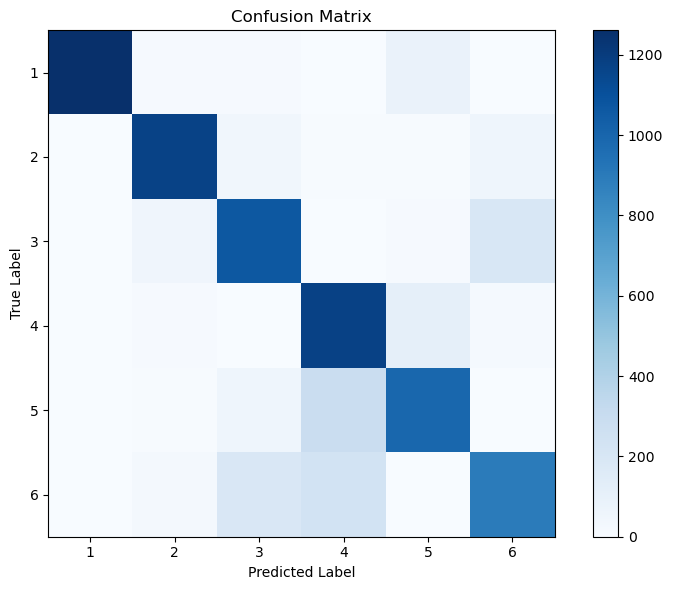

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

@torch.no_grad()
def evaluate_full(model: nn.Module, dataloader: DataLoader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim = 1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y_batch.numpy())
    
    return np.concatenate(all_labels), np.concatenate(all_preds)

y_true, y_pred = evaluate_full(model, test_loader, device)
print(classification_report(y_true, y_pred, digits = 4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize = (8, 6))
plt.imshow(cm, interpolation = "nearest", cmap = plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [inv_label_map[i] for i in range(num_classes)])
plt.yticks(tick_marks, [inv_label_map[i] for i in range(num_classes)])
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Check Class Imbalance

In [22]:
print(pd.Series(y_train_encoded).value_counts().sort_index())

0    5975
1    5848
2    5986
3    6124
4    6119
5    6148
Name: count, dtype: int64


# Plot Training Curves

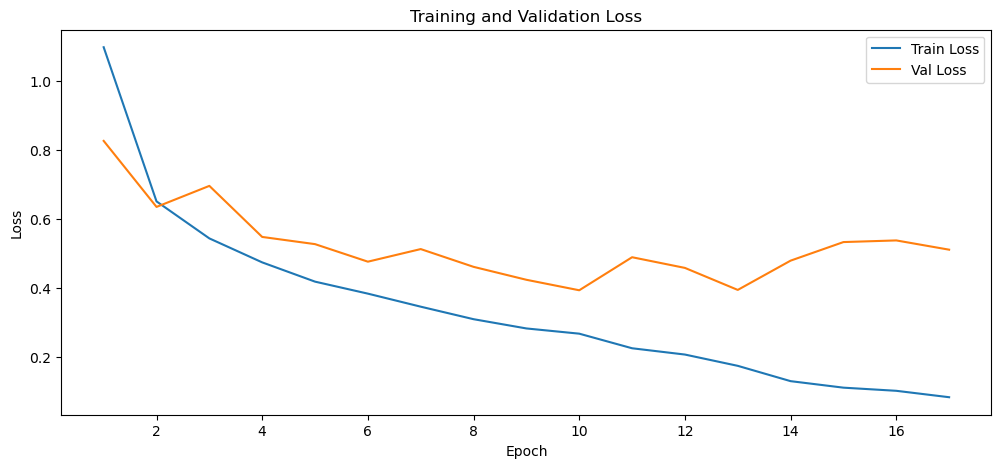

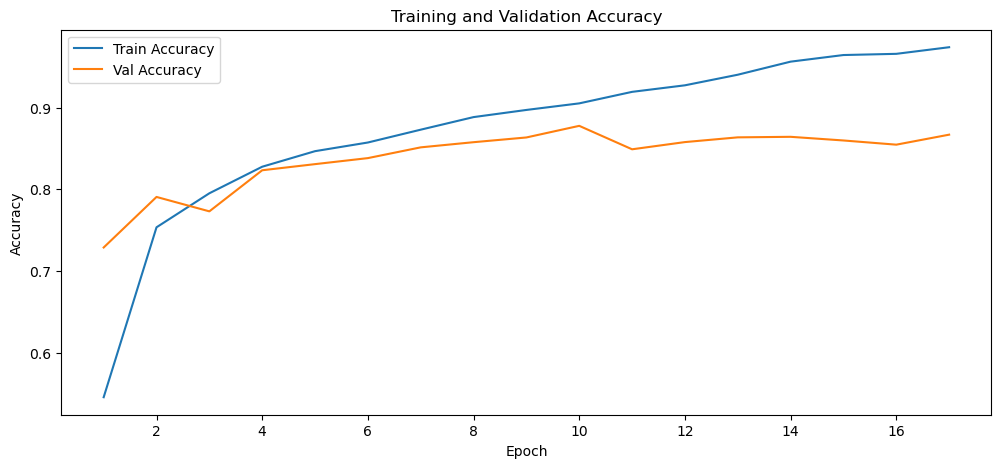

In [23]:
hist = pd.DataFrame(history)
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_loss"], label = "Train Loss")

if "val_loss" in hist.columns:
    plt.plot(hist["epoch"], hist["val_loss"], label = "Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_accuracy"], label = "Train Accuracy")

if "val_accuracy" in hist.columns:
    plt.plot(hist["epoch"], hist["val_accuracy"], label = "Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

# Save the Model

In [24]:
out = Path("artifacts")
out.mkdir(exist_ok = True)

torch.save(best_model_state, out / "best_model_v3.pt")

meta = {
    "window_len": cfg.window_size,
    "step_size": cfg.step_size,
    "num_channels": num_channels,
    "num_classes": num_classes,
    "label_map": {int(k): int(v) for k, v in label_map.items()},
    "inverted_label_map": {int(k): int(v) for k, v in inv_label_map.items()}  
}

with open(out / "metadata_v3.json", "w") as f:
    json.dump(meta, f, indent = 2)

print("Saved model and metadata to", out.resolve())


Saved model and metadata to /Users/tonyliu/Documents/EMGTuner-master/artifacts
